# Simulação Computacional: Operações com Sinais

Para investigar as operações fundamentais em tempo discreto, definimos um sinal base $x[n]$ assimétrico, modelando um pulso transitório de tensão com suporte finito (amostras de $n=0$ a $n=4$). 
A assimetria é crucial para podermos visualizar claramente as diferenças entre o sinal original e a sua inversão temporal.

As seis operações exigidas investigadas são:
1. Sinal original: $x[n]$
2. Atraso no tempo: $x[n-2]$
3. Avanço no tempo: $x[n+2]$
4. Inversão temporal: $x[-n]$
5. Escalonamento de amplitude: $2x[n]$
6. Inversão de amplitude: $-x[n]$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

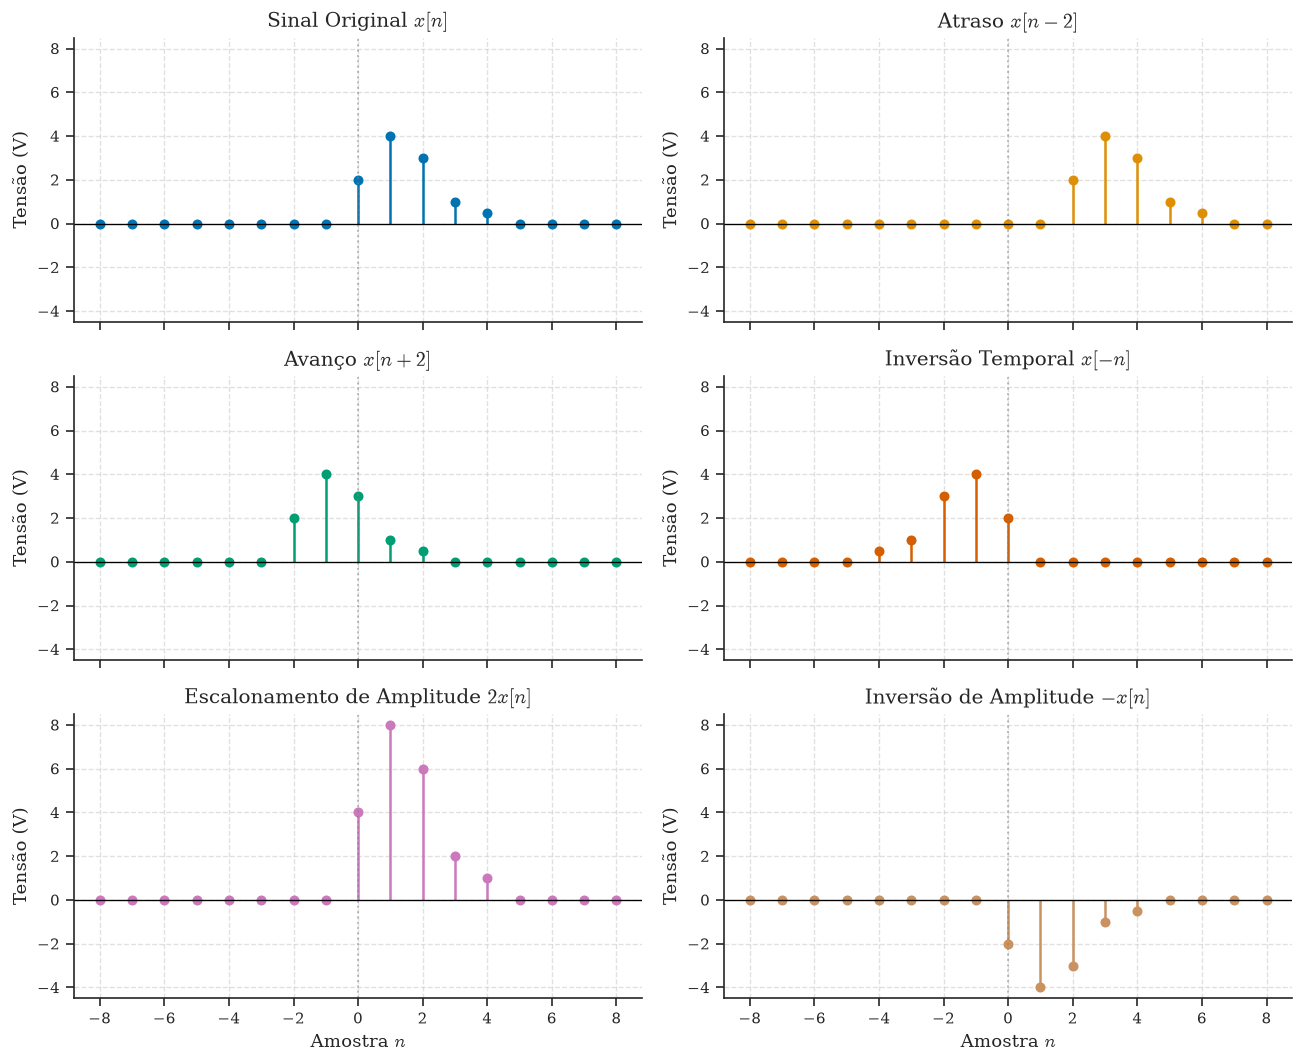

In [2]:
# 1. Definição do vetor de amostras genérico (eixo n)
n = np.arange(-8, 9)

# 2. Definição da função matemática do sinal base x[n]
def sinal_x(n_vec):
    """
    Gera um pulso transitório assimétrico.
    Amplitudes: 2V, 4V (pico), 3V, 1V, 0.5V nos instantes n = 0, 1, 2, 3, 4.
    """
    x = np.zeros_like(n_vec, dtype=float)
    valores = np.array([2.0, 4.0, 3.0, 1.0, 0.5])
    for i, val in enumerate(valores):
        x[n_vec == i] = val
    return x

# 3. Geração das operações matemáticas
operacoes = [
    (sinal_x(n),       r"Sinal Original $x[n]$",            "C0"),
    (sinal_x(n - 2),   r"Atraso $x[n-2]$",                  "C1"),
    (sinal_x(n + 2),   r"Avanço $x[n+2]$",                  "C2"),
    (sinal_x(-n),      r"Inversão Temporal $x[-n]$",        "C3"),
    (2 * sinal_x(n),   r"Escalonamento de Amplitude $2x[n]$", "C4"),
    (-sinal_x(n),      r"Inversão de Amplitude $-x[n]$",    "C5"),
]

# 4. Configuração da Figura (Painel 3x2)
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for ax, (seq, titulo, cor) in zip(axes, operacoes):
    markerline, stemlines, baseline = ax.stem(
        n, seq, linefmt="-", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, color=cor, linewidth=1.5)
    plt.setp(markerline, color=cor, markersize=5)
    
    # Destacar eixos principais
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_title(titulo)
    ax.set_ylabel("Tensão (V)")
    ax.set_ylim(-4.5, 8.5)  # Eixo Y fixo para permitir comparação direta de amplitude
    ax.set_xticks(np.arange(-8, 9, 2))

axes[-2].set_xlabel(r"Amostra $n$")
axes[-1].set_xlabel(r"Amostra $n$")

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_operacoes.png")
plt.show()